# Model Comparison: Bank Customer Churn
This notebook compares all available model results for customer churn prediction.

In [3]:
# 1. Load Metrics from All Models
import os
import json
import pandas as pd

metrics_dir = '../outputs/metrics/'
metrics_files = [f for f in os.listdir(metrics_dir) if f.endswith('_metrics.json')]

results = []
for file in metrics_files:
    with open(os.path.join(metrics_dir, file), 'r') as f:
        data = json.load(f)
        results.append(data)

results_df = pd.DataFrame(results)
results_df = results_df[['model', 'accuracy', 'precision', 'recall', 'f1']]
results_df = results_df.sort_values(by='accuracy', ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1
0,Random Forest,0.8515,0.857143,0.324324,0.470588
1,Decision Tree,0.8100,0.531765,0.555283,0.543269
2,SVM,0.7110,0.381743,0.678133,0.488496
3,Logistic Regression,0.7090,0.380628,0.685504,0.489474


C:\Users\JINADARI\AppData\Local\Temp\ipykernel_11104\1532008555.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y='accuracy', palette='viridis')


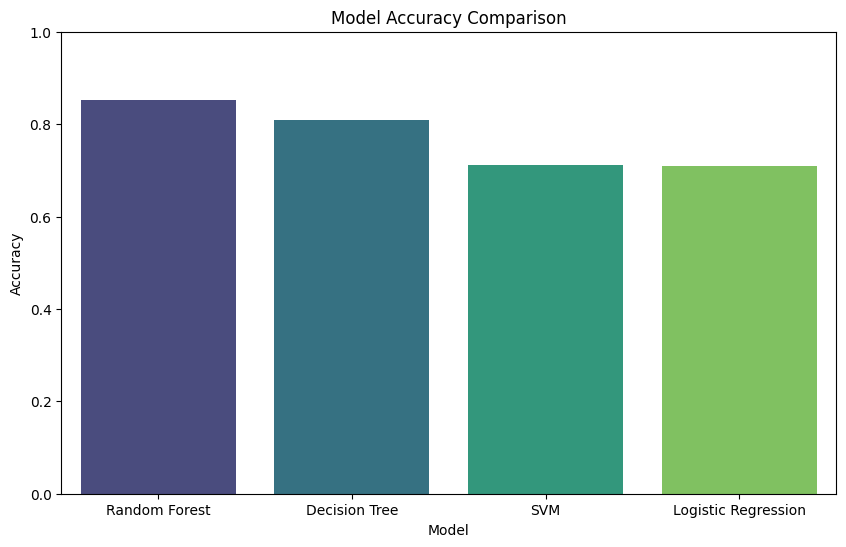

In [4]:
# 2. Visualize Model Comparison
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='model', y='accuracy', palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.show()

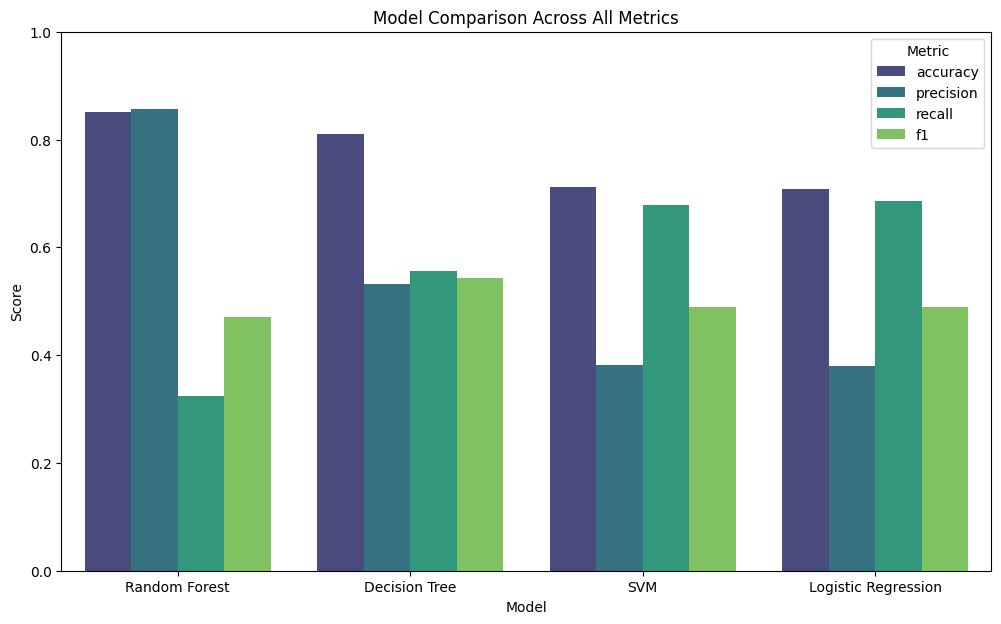

In [5]:
# 3. Compare All Metrics (Accuracy, Precision, Recall, F1)
plt.figure(figsize=(12, 7))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
results_melted = results_df.melt(id_vars='model', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='model', y='Score', hue='Metric', palette='viridis')
plt.title('Model Comparison Across All Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.show()